In [1]:
# %matplotlib ipympl

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import pyPPG
import pyPPG.example
import scipy.io
import scipy.signal
from matplotlib import pyplot as plt

In [3]:
data_dir = Path('data')

In [4]:
csv_dir = data_dir / 'csvs'

In [5]:
ppg_dir = data_dir / 'ppg'

In [18]:
pyppg_dir = data_dir / 'pyppg'

In [6]:
subjects_path = csv_dir / 'subjects.csv'

In [7]:
df_subjects = pd.read_csv(csv_dir / 'subjects.csv')

In [8]:
df_subjects['patient_file'] = df_subjects.apply(lambda r: ppg_dir / f'p{r["subject_id"]:06d}_{r["segment_id"]}.mat', axis=1)

In [9]:
subject_id, category, patient_file = df_subjects.loc[1, ['subject_id', 'class', 'patient_file']]

In [10]:
fs = 125

In [11]:
mat = scipy.io.loadmat(patient_file)

In [12]:
t = mat['time'].squeeze()
ppg_raw = mat['data'].squeeze()

In [14]:
b, a = scipy.signal.cheby2(4, 20, 30, fs=fs)
ppg_cheby = scipy.signal.filtfilt(b, a, ppg_raw)

In [15]:
b, a = scipy.signal.butter(4, 30, fs=fs)
ppg_butter = scipy.signal.filtfilt(b, a, ppg_raw)

In [19]:
ppg = ppg_raw
# ppg = ppg_cheby
# ppg = ppg_butter
temp_file = pyppg_dir / 'temp' / patient_file.name
scipy.io.savemat(temp_file, {'Fs': fs, 'Data': ppg_raw})

/home/thulio/.venvs/rsch/lib/python3.12/site-packages/pyPPG/fiducials.py:68: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  ppg_fp[keys[n]][0:len(temp_val)]=temp_val
/home/thulio/.venvs/rsch/lib/python3.12/site-packages/pyPPG/fiducials.py:68:

Fiducial points:
                    on     sp     dn     dp    off      u      v      w      a  \
Index of pulse                                                                  
0                   0     35     53   <NA>     94     21     45     65     14   
1                  94    122    140   <NA>    179    107    131    145     99   
2                 179    206    226   <NA>    265    192    216    233    184   
3                 265    291    311   <NA>    351    277    302    318    269   
4                 351    377    400   <NA>    436    363    386    394    355   
...               ...    ...    ...    ...    ...    ...    ...    ...    ...   
434             36774  36798  36818  36826  36853  36785  36807  36825  36778   
435             36853  36878  36898   <NA>  36934  36865  36888   <NA>  36858   
436             36934  36959  36978   <NA>  37016  36946  36969  36991  36939   
437             37016  37040  37060   <NA>  37098  37028  37050  37068  37020   
438       

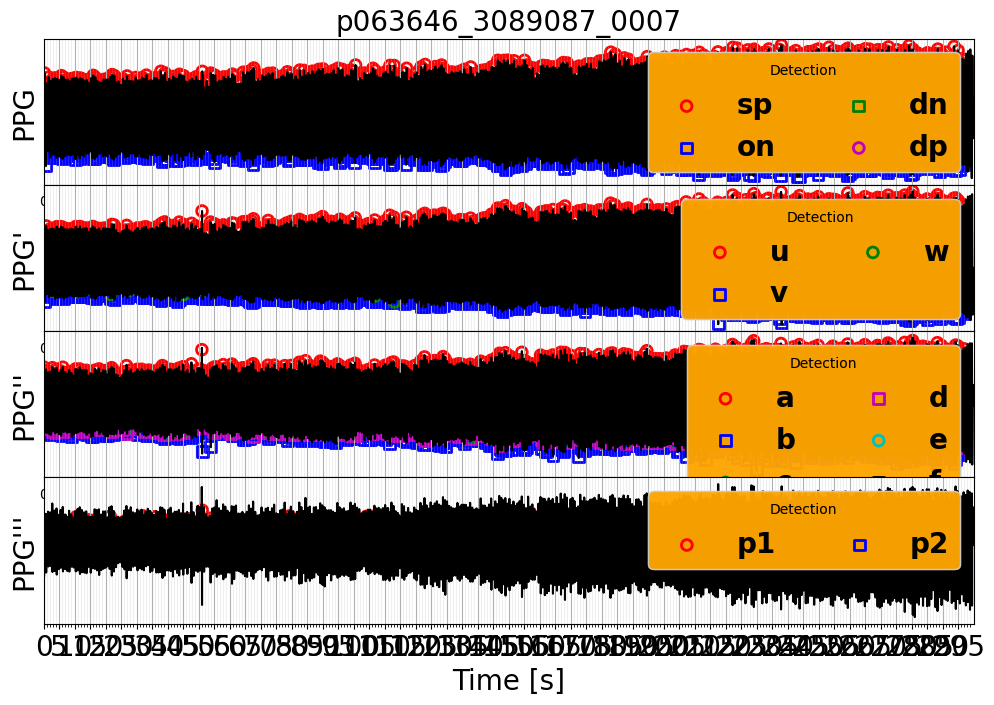

Figure has been saved in the "temp_dir/PPG_Figures/".
Statistics of the biomarkers:
ppg_sig 
                     Tpi       Tpp      Tsys      Tdia        Tsp       Tdp  \
Statistics                                                                   
mean           0.677589  0.677388  0.366210  0.236170   0.206995  0.443976   
median         0.680000  0.680000  0.368000  0.240000   0.208000  0.440000   
std            0.020692  0.019560  0.013634  0.034198   0.009254  0.031898   
percentile_25  0.664000  0.664000  0.360000  0.224000   0.200000  0.424000   
percentile_75  0.688000  0.688000  0.368000  0.256000   0.208000  0.448000   
iqr            0.024000  0.024000  0.008000  0.032000   0.008000  0.024000   
skew           0.262465  0.129459  1.585326 -0.337181   1.829945  0.587660   
kurtosis       0.967909  0.709424  4.815675  0.958677  13.306593  1.768554   
mad            0.015657  0.015226  0.009729  0.025314   0.006358  0.022418   

                 deltaT     Tsw10     Tsw25    

In [20]:
s, fp, bm = pyPPG.example.ppg_example(
    data_path=temp_file.as_posix(),
    # filtering=False,
    filtering=True,
    # fL=0,
    # fH=30,
    # plotfig=False,
    # savefig=False,
    # savedata=False
)

In [21]:
fp.get_fp()

,on,sp,dn,dp,off,u,v,w,a,b,c,d,e,f,p1,p2
Index of pulse,,,,,,,,,,,,,,,,
0,0,35,53,<NA>,94,21,45,65,14,26,32,36,50,65,29,36
1,94,122,140,<NA>,179,107,131,145,99,112,120,120,136,145,115,120
2,179,206,226,<NA>,265,192,216,233,184,200,212,212,223,233,212,227
3,265,291,311,<NA>,351,277,302,318,269,284,293,293,308,318,289,293
4,351,377,400,<NA>,436,363,386,394,355,370,372,374,391,394,371,374
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
434,36774,36798,36818,36826,36853,36785,36807,36825,36778,36791,36798,36798,36813,36827,36794,36798
435,36853,36878,36898,<NA>,36934,36865,36888,<NA>,36858,36871,36878,36878,36894,36906,36875,36878
436,36934,36959,36978,<NA>,37016,36946,36969,36991,36939,36951,36960,36961,36974,36991,36954,36961


In [22]:
fp.get_fp().isna().sum()

on       0
sp       0
dn       0
dp     274
off      0
u        0
v        0
w       91
a        0
b        0
c        0
d        0
e        0
f        0
p1       0
p2       0
dtype: int64

In [24]:
bm.get_bm()

,bm_defs,bm_vals,bm_stats
ppg_sig,name ...,name TimeStamp Tpi Tpp Tsys...,Tpi Tpp Tsys ...
sig_ratios,name \ No. biomarker...,name TimeStamp IPR Tsys/Tdi...,IPR Tsys/Tdia Tpw25/Tpi...
ppg_derivs,name ...,name TimeStamp Tu Tv Tw...,Tu Tv Tw ...
derivs_ratios,name \ No. biomarkers ...,name TimeStamp Tu/Tpi Tv/Tpi ...,Tu/Tpi Tv/Tpi Tw/Tpi ...


In [25]:
bm.bm_defs

{'ppg_sig':                   name                                         definition  \
 No. biomarkers                                                              
 1                  Tpi  Pulse interval, the time between the pulse ons...   
 2                  Tpp  Peak-to-peak interval, the time between two co...   
 3                 Tsys  Systolic time, the time between the pulse onse...   
 4                 Tdia  Diastolic time, the time is between the dicrot...   
 5                  Tsp  Systolic peak time, the time between the pulse...   
 6                  Tdp  Diastolic peak time, the time between the puls...   
 7               deltaT  Time delay, the time between the systolic peak...   
 8                Tsw10  Systolic width, the width at 10% of the systol...   
 9                Tsw25  Systolic width, the width at 25% of the systol...   
 10               Tsw33  Systolic width, the width at 33% of the systol...   
 11               Tsw50  Systolic width, the width at

In [26]:
bm.bm_stats

{'ppg_sig':                     Tpi       Tpp      Tsys      Tdia        Tsp       Tdp  \
 Statistics                                                                   
 mean           0.677589  0.677388  0.366210  0.236170   0.206995  0.443976   
 median         0.680000  0.680000  0.368000  0.240000   0.208000  0.440000   
 std            0.020692  0.019560  0.013634  0.034198   0.009254  0.031898   
 percentile_25  0.664000  0.664000  0.360000  0.224000   0.200000  0.424000   
 percentile_75  0.688000  0.688000  0.368000  0.256000   0.208000  0.448000   
 iqr            0.024000  0.024000  0.008000  0.032000   0.008000  0.024000   
 skew           0.262465  0.129459  1.585326 -0.337181   1.829945  0.587660   
 kurtosis       0.967909  0.709424  4.815675  0.958677  13.306593  1.768554   
 mad            0.015657  0.015226  0.009729  0.025314   0.006358  0.022418   
 
                  deltaT     Tsw10     Tsw25     Tsw33  ...     Tpw66  \
 Statistics                                  

In [27]:
bm.bm_vals

{'ppg_sig': name            TimeStamp    Tpi    Tpp   Tsys   Tdia    Tsp    Tdp  deltaT  \
 Index of pulse                                                                
 1                       0  0.752  0.696  0.424    NaN  0.280    NaN     NaN   
 2                      94  0.680  0.672  0.368    NaN  0.224    NaN     NaN   
 3                     179  0.688  0.680  0.376    NaN  0.216    NaN     NaN   
 4                     265  0.688  0.688  0.368    NaN  0.208    NaN     NaN   
 5                     351  0.680  0.680  0.392    NaN  0.208    NaN     NaN   
 ...                   ...    ...    ...    ...    ...    ...    ...     ...   
 434                 36691  0.664  0.656  0.360    NaN  0.200    NaN     NaN   
 435                 36774  0.632  0.640  0.352  0.216  0.192  0.416   0.224   
 436                 36853  0.648  0.648  0.360    NaN  0.200    NaN     NaN   
 437                 36934  0.656  0.648  0.352    NaN  0.200    NaN     NaN   
 438                 37016  0

(0.0, 10.0)

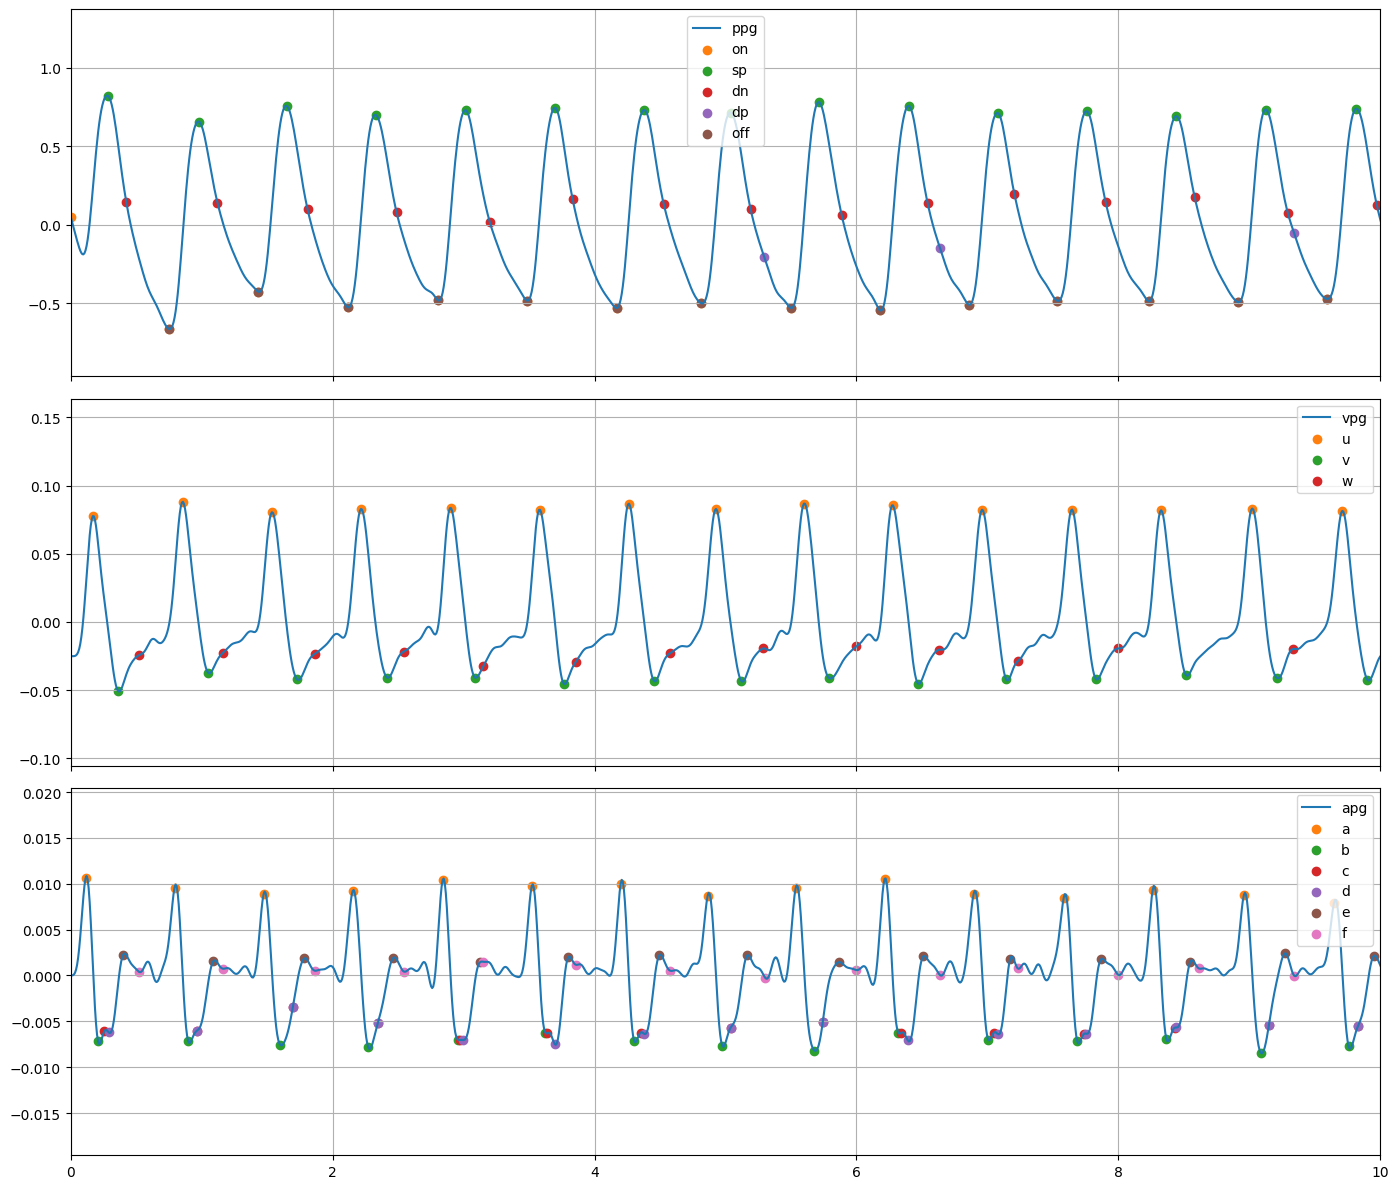

In [28]:
def plot_column(t: np.typing.ArrayLike, s: np.typing.ArrayLike, df: pd.DataFrame, col: str, ax: plt.Axes, color: str):
    indices = df[col].dropna()
    ax.scatter(t[indices], s[indices], color=color)

fig, axes = plt.subplots(3, 1, sharex=True, figsize=(14, 12))
axes: tuple[plt.Axes]

axes[0].plot(t, s.ppg, color='C0')
axes[1].plot(t, s.vpg, color='C0')
axes[2].plot(t, s.apg, color='C0')

df_fp = fp.get_fp()

plot_column(t, s.ppg, df_fp, 'on', axes[0], color='C1')
plot_column(t, s.ppg, df_fp, 'sp', axes[0], color='C2')
plot_column(t, s.ppg, df_fp, 'dn', axes[0], color='C3')
plot_column(t, s.ppg, df_fp, 'dp', axes[0], color='C4')
plot_column(t, s.ppg, df_fp, 'off', axes[0], color='C5')

axes[0].legend(['ppg', 'on', 'sp', 'dn', 'dp', 'off'])

plot_column(t, s.vpg, df_fp, 'u', axes[1], color='C1')
plot_column(t, s.vpg, df_fp, 'v', axes[1], color='C2')
plot_column(t, s.vpg, df_fp, 'w', axes[1], color='C3')

axes[1].legend(['vpg', 'u', 'v', 'w'])

plot_column(t, s.apg, df_fp, 'a', axes[2], color='C1')
plot_column(t, s.apg, df_fp, 'b', axes[2], color='C2')
plot_column(t, s.apg, df_fp, 'c', axes[2], color='C3')
plot_column(t, s.apg, df_fp, 'd', axes[2], color='C4')
plot_column(t, s.apg, df_fp, 'e', axes[2], color='C5')
plot_column(t, s.apg, df_fp, 'f', axes[2], color='C6')

axes[2].legend(['apg', 'a', 'b', 'c', 'd', 'e', 'f'])

axes[0].grid(True)
axes[1].grid(True)
axes[2].grid(True)

fig.tight_layout()

plt.xlim(0, 10)